In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

**Ensemble learning aggregates predictions from multiple base models to enhance robustness and accuracy, leveraging diversity among models to mitigate individual weaknesses such as high variance in unconstrained decision trees, while preserving interpretability and flexibility.**

## Introduction to Ensemble Learning
Ensemble learning constructs a meta-model by combining outputs from diverse base learners trained on the same dataset. This approach capitalises on the principle that collective decision-making outperforms individual models, particularly when base models err in uncorrelated ways. By averaging or voting on predictions, ensembles reduce error variance and improve generalisation, addressing limitations like overfitting in single models.

The rationale stems from statistical averaging: if base models are unbiased but high-variance, their ensemble lowers overall variance without increasing bias. Ensembles excel in scenarios where base models, such as classification and regression trees (CARTs), exhibit flexibility but instability.

### Advantages and Limitations of CARTs
**Classification and regression trees** (CARTs) offer several strengths as base learners. They require minimal preprocessing, as splits operate independently on features without needing standardisation or normalisation. CARTs inherently capture non-linear relationships and interactions, producing interpretable rules via hierarchical structures. Their simplicity facilitates visualisation and understanding, making them accessible for exploratory analysis.

However, CARTs suffer drawbacks that ensembles address. In classification, they generate axis-aligned decision boundaries, limiting expressiveness for oblique patterns. Unconstrained trees exhibit high variance, sensitive to training perturbations—a single data point's removal can alter the structure significantly. This leads to overfitting, where the model memorises noise rather than signal. Ensembles mitigate this by diversifying learners, stabilising predictions.


### Theoretical Foundations of Ensemble Learning
Ensemble methods reduce generalisation error by decomposing it into bias, variance, and irreducible noise. For a predictor $\hat{f}$, the expected error is:
$$
E[(y - \hat{f}(\mathbf{x}))^2] = \text{Bias}^2[\hat{f}] + \text{Var}[\hat{f}] + \sigma^2.
$$
Base models like CARTs often have low bias but high variance. An ensemble of $M$ independent predictors $\hat{f}_m$ with predictions averaged as $\bar{f} = \frac{1}{M} \sum_{m=1}^M \hat{f}_m$ yields:
$$
\text{Var}[\bar{f}] = \frac{1}{M} \text{Var}[\hat{f}_m],
$$
assuming identical variance across models. This variance reduction enhances stability, provided models are diverse—correlated errors diminish benefits.

Diversity arises from varying algorithms, hyperparameters, or data subsets. In practice, ensembles assume weak correlation among base errors, ensuring the meta-model compensates individual flaws.

For classification, **hard voting** aggregates class labels: the meta-model selects the mode of base predictions. For $N$ classifiers outputting $P_i \in \{0, 1\}$, the ensemble prediction is $\arg\max_k \sum_i \mathbb{I}(P_i = k)$, where $\mathbb{I}$ is the indicator function. This majority rule robustifies against outliers.

### Ensemble Methods in Practice
Ensembles train base models—potentially heterogeneous like decision trees, logistic regression, and k-nearest neighbours—on the dataset. Each base outputs predictions, aggregated by a meta-model. For regression, averaging suffices; for classification, voting prevails.

This diversity ensures skilful yet complementary performance: one model's strength offsets another's weakness. The meta-model, often simple (e.g., majority vote), yields predictions less prone to errors, improving robustness on unseen data.

To illustrate conceptually:

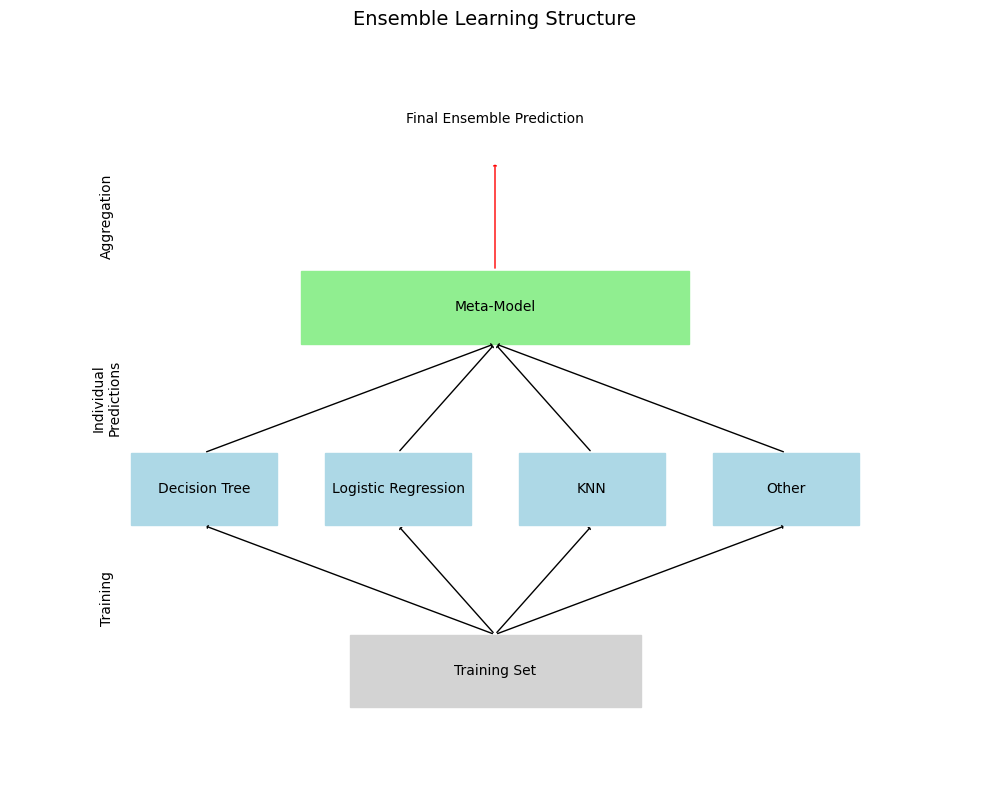

In [5]:
from matplotlib.patches import ArrowStyle, FancyArrowPatch, Rectangle

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

# Training set
ax.add_patch(Rectangle((3.5, 1), 3, 1, fill=True, color="lightgrey"))
ax.text(5, 1.5, "Training Set", ha="center", va="center")

# Base models
models = ["Decision Tree", "Logistic Regression", "KNN", "Other"]
x_pos = [2, 4, 6, 8]
for i, model in enumerate(models):
	ax.add_patch(
		Rectangle((x_pos[i] - 0.75, 3.5), 1.5, 1, fill=True, color="lightblue")
	)
	ax.text(x_pos[i], 4, model, ha="center", va="center")

# Arrows from training set to base models
for x in x_pos:
	arrow = FancyArrowPatch(
		(5, 2), (x, 3.5), arrowstyle=ArrowStyle("->", head_width=1), color="black"
	)
	ax.add_patch(arrow)

# Meta-model
ax.add_patch(Rectangle((3, 6), 4, 1, fill=True, color="lightgreen"))
ax.text(5, 6.5, "Meta-Model", ha="center", va="center")

# Arrows from base models to meta-model
for x in x_pos:
	arrow = FancyArrowPatch(
		(x, 4.5), (5, 6), arrowstyle=ArrowStyle("->", head_width=1), color="black"
	)
	ax.add_patch(arrow)

# Final prediction
arrow = FancyArrowPatch(
	(5, 7), (5, 8.5), arrowstyle=ArrowStyle("->", head_width=1), color="red"
)
ax.add_patch(arrow)
ax.text(5, 9, "Final Ensemble Prediction", ha="center", va="bottom")

# Add labels for clarity
ax.text(1, 2.5, "Training", ha="center", va="center", rotation=90, fontsize=10)
ax.text(
	1,
	5.25,
	"Individual\nPredictions",
	ha="center",
	va="center",
	rotation=90,
	fontsize=10,
)
ax.text(1, 7.75, "Aggregation", ha="center", va="center", rotation=90, fontsize=10)

ax.set_title("Ensemble Learning Structure", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


This diagram depicts the flow from data to aggregated output.

### Voting Classifier for Classification
In binary classification, a **voting classifier** employs hard voting: base classifiers predict labels, and the meta-model selects the majority class. This reduces error probability, as the ensemble errs only if over half the bases err, assuming independence.

For multi-class, it generalises to plurality voting. Weighted voting assigns importance to bases, but uniform weights suffice for balanced ensembles.

### Implementation in Scikit-Learn
Scikit-learn's `VotingClassifier` integrates base estimators, aggregating via hard ('hard') or soft voting (probabilities, 'soft'). Use on real datasets like Wisconsin Breast Cancer for binary classification.

Self-contained example:

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Load Wisconsin Breast Cancer dataset (569 samples, 30 features, binary classification)
data = load_breast_cancer()
X, y = data.data, data.target  # Features: cell measurements, labels: 0=malignant, 1=benign

# Split dataset: 70% for training base models, 30% for testing ensemble performance
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.3, random_state=42
)

# Initialize diverse base classifiers to ensure complementary strengths
# Logistic Regression: linear decision boundary, low variance, stable predictions
log_reg = LogisticRegression(max_iter=10000, random_state=42)
# Decision Tree: non-linear, high variance, prone to overfitting but captures interactions
dt_clf = DecisionTreeClassifier(random_state=42)
# K-Nearest Neighbors: instance-based, sensitive to local patterns, no explicit model
knn_clf = KNeighborsClassifier()

# Store estimators as (name, classifier) tuples for VotingClassifier
estimators = [
	("Logistic Regression", log_reg),
	("Decision Tree", dt_clf),
	("K-Nearest Neighbors", knn_clf),
]

# Evaluate individual base classifiers to establish baseline performance
print("Base Classifier Performance:")
for name, clf in estimators:
	clf.fit(X_train, y_train)
	y_pred = clf.predict(X_test)
	acc = accuracy_score(y_test, y_pred)
	print(f"  {name} Accuracy: {acc:.3f}")

# Create voting ensemble using hard voting (majority rule for class labels)
# Aggregates predictions: final class = mode of base predictions
# Reduces variance by combining diverse models, improving generalization
voting_clf = VotingClassifier(estimators=estimators, voting="hard")
voting_clf.fit(X_train, y_train)  # Train all base models simultaneously
y_pred_ensemble = voting_clf.predict(X_test)  # Aggregate predictions via majority vote
ensemble_acc = accuracy_score(y_test, y_pred_ensemble)

print(f"Ensemble Accuracy: {ensemble_acc:.3f}")


Logistic Regression Accuracy: 0.947
Decision Tree Accuracy: 0.930
K-Nearest Neighbors Accuracy: 0.930
Ensemble Accuracy: 0.953


This evaluates bases and ensemble, typically showing ensemble superiority.

For visualisation, compare decision boundaries if reduced to 2D, but omit for high dimensions.

### Practical Considerations and Extensions
Ensembles demand computational resources, scaling with base count, but parallelisation mitigates this. Base diversity—via algorithms or bootstrapping—maximises gains. For regression, `VotingRegressor` averages continuous outputs.

Theoretically, ensembles approximate Bayes optimal classifiers under diversity, reducing variance-dominant errors. Limitations include diminished interpretability versus single trees. Advanced variants like bagging or boosting further refine, but voting provides a foundational, model-agnostic approach.